In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zona_logistica\esp840_1620_02_2026.csv',sep=',') #for csv files.
#unit=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx') #For xls files.
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 12896 entries, 0 to 12895
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  12896 non-null  str  
 1   Message  12896 non-null  str  
 2   Status   12896 non-null  str  
dtypes: str(3)
memory usage: 302.4 KB


Odometer

      Odometer in  Odometer en miles
0       123849381       76956.413721
1       123849381       76956.413721
2       123849381       76956.413721
3       123849381       76956.413721
4       123849381       76956.413721
...           ...                ...
1907    125183859       77785.619651
1908    125183928       77785.662525
1909    125183940       77785.669982
1910    125183961       77785.683031
1911    125183961       77785.683031

[1912 rows x 2 columns]


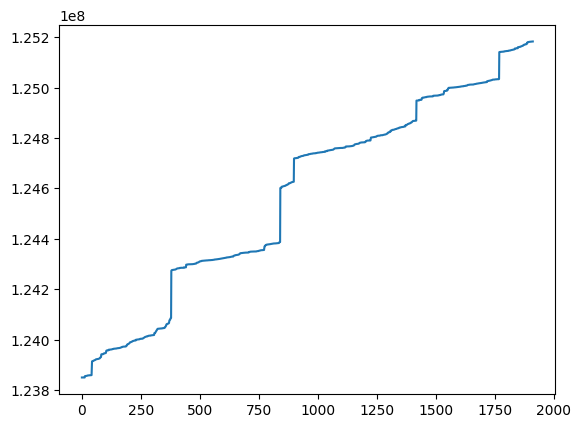

In [3]:
aux=[]
aux_miles=[]
x_axis=[]
unit_odometer=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][68:76],16))
        aux_miles.append((int(unit.iloc[i,2][68:76],16))*0.000621371)
        cont=cont+1     

unit_odometer['Odometer in']=aux
unit_odometer['Odometer en miles']=aux_miles

for i in range(0,cont):
    x_axis.append(i)

print(unit_odometer)
unit_odometer
plt.plot(x_axis,aux)

Harsh turn

Event codes only for No User messages.
Harsh Turn: 35 on Hex, 53 on Dec

In [4]:
event_code=[]

for i in range(0,unit.shape[0]):
    event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='35': # Put the Even Code to look for.
        print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])

35  ->  2026-02-16 16:42:44.497
35  ->  2026-02-16 19:26:02.674


Satellite number

In [5]:
cont=0
for i in range(0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    if l>92:
        sn=int(unit.iloc[i,2][82:84],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1
    if l<93:
        sn=int(unit.iloc[i,2][55:57],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1

print('Messages with satellite number < 5: ',cont)
        

2026-02-16 00:00:31.318  ->  2
2026-02-16 00:01:11.161  ->  2
2026-02-16 00:01:50.995  ->  2
2026-02-16 00:02:30.918  ->  2
2026-02-16 00:03:10.765  ->  2
2026-02-16 00:03:50.976  ->  2
2026-02-16 00:04:30.437  ->  2
2026-02-16 00:05:10.356  ->  2
2026-02-16 00:05:50.195  ->  2
2026-02-16 00:06:30.038  ->  2
2026-02-16 00:07:09.861  ->  2
2026-02-16 00:07:49.960  ->  2
2026-02-16 00:08:30.692  ->  2
2026-02-16 00:09:09.474  ->  2
2026-02-16 00:09:49.398  ->  2
2026-02-16 00:10:29.218  ->  2
2026-02-16 00:11:09.079  ->  2
2026-02-16 00:11:48.997  ->  2
2026-02-16 00:12:28.829  ->  2
2026-02-16 00:13:08.658  ->  2
2026-02-16 00:13:48.502  ->  2
2026-02-16 00:14:28.433  ->  2
2026-02-16 00:15:08.256  ->  2
2026-02-16 00:15:48.132  ->  2
2026-02-16 00:16:28.009  ->  2
2026-02-16 00:17:07.855  ->  2
2026-02-16 00:17:47.693  ->  2
2026-02-16 00:18:27.625  ->  2
2026-02-16 00:19:07.469  ->  2
2026-02-16 00:19:47.294  ->  2
2026-02-16 00:20:27.224  ->  2
2026-02-16 00:21:07.050  ->  2
2026-02-

Temperature

In [8]:
accum3=float(input('Type Accum 3 value: '))
celsius_temp=accum3*0.0625
farenheit_temp=(celsius_temp*9)/5+32
print('Celsius: ',celsius_temp,'farenheit: ',farenheit_temp)

Celsius:  25.0 farenheit:  77.0


Binary inputs

In [7]:
for i in range(0,unit.shape[0]):   
    if unit.iloc[i,2][64:66]=='0C': # Put the Even Code to look for.
        cont=cont+1
        print(bin(int(unit.iloc[i,2][62:64],16)),' -> ',unit.iloc[i,0])
print("Total event codes 0C input2 Off: ",cont)

0b10  ->  2026-02-20 18:16:02.210
Total event codes 0C input2 Off:  9960


In [8]:
sequence=[]
sequence.append(unit.iloc[0,2][24:28])
sequence

['9336']

[0, 0, 0, 0, 0, 0, 0, 0, 0, 20, 30, 22, 31, 36, 47, 47, 49, 41, 32, 31, 34, 34, 34, 48, 18, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 8, 10, 10, 14, 12, 15, 27, 29, 22, 29, 24, 26, 30, 44, 49, 45, 44, 44, 49, 49, 49, 13, 34, 27, 0, 38, 28, 0, 37, 41, 37, 36, 36, 35, 38, 27, 27, 34, 41, 39, 44, 44, 45, 40, 40, 37, 39, 39, 33, 29, 25, 25, 23, 21, 36, 39, 39, 38, 48, 46, 47, 50, 51, 38, 48, 44, 51, 40, 48, 25, 22, 24, 24, 24, 44, 9, 29, 34, 26, 22, 23, 16, 21, 24, 13, 13, 9, 26, 25, 27, 14, 17, 16, 14, 20, 12, 9, 28, 30, 31, 22, 22, 34, 25, 20, 26, 23, 21, 18, 24, 21, 21, 22, 20, 21, 11, 28, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0, 2, 0, 23, 8, 0, 0, 0, 1, 0, 15, 11, 8, 17, 15, 18, 14, 10, 16, 15, 0, 12, 11, 21, 23, 24, 18, 20, 26, 21, 24, 14, 9, 18, 18, 10, 9, 9, 13, 26, 26, 13, 30, 17, 13, 26, 20, 8, 19, 21, 16, 32, 26, 28, 29, 10, 15, 9, 24, 34, 19, 19, 19, 0, 34, 49, 44, 0, 32, 36, 0, 36, 32, 38, 44, 32, 33, 34, 28, 30, 27, 36, 46, 52, 58, 4

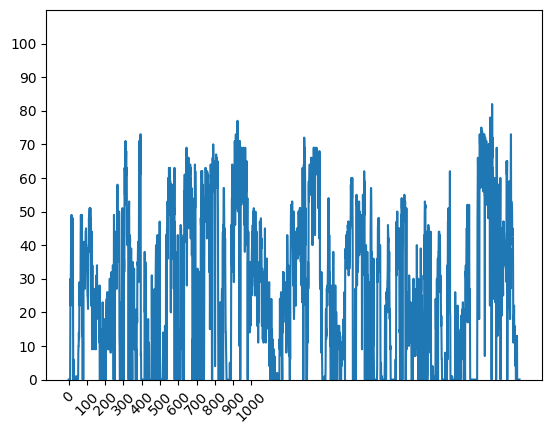

In [8]:
aux=[]
aux_kmh=[]
x_axis=[]
unit_speed=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        #aux_kmh.append((int(unit.iloc[i,2][68:76],16))*0.036)
        cont=cont+1     

unit_speed['Speed Km-h']=aux
#unit_speed['Speed m-s']=aux_kmh

for i in range(0,cont):
    x_axis.append(i)

print(aux,cont)

plt.xticks(range(0,1100,100),rotation=45)
plt.yticks(range(0,110,10))
plt.ylim(0,110)
plt.plot(x_axis,aux)